# COE 311K: Live Coding Lecture - Implementing Euler's Backward with Newton-Raphson

## Lecture Overview

**Format:** Interactive coding session - students follow along in their own Jupyter notebooks

**Goal:** Build a working implicit solver from scratch, understanding each piece

**Problem we'll solve:** 
$$\frac{dy}{dt} = -1000(y - \cos(t)) - \sin(t)$$
with $y(0) = 1$, solve from $t = 0$ to $t = 10$

**Why this problem?**
- Analytical solution: $y(t) = \cos(t)$ (we can check our answer!)
- Very stiff: $\lambda = 1000$ means fast decay
- Slow forcing: $\cos(t)$ varies on $O(1)$ time scale
- **Stiffness ratio:** $\sim 1000$

## Part 1: Setup and Understanding the Problem (10 minutes)

### Step 1.1: Import Libraries and Define the Problem


```python
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
lam = 1000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y)
def f(t, y):
    """
    Right-hand side of the ODE.
    dy/dt = -1000(y - cos(t)) - sin(t)
    
    This is in the form: dy/dt = -lambda*y + g(t)
    where g(t) = lambda*cos(t) - sin(t)
    """
    return -lam * (y - np.cos(t)) - np.sin(t)

# Analytical solution (for verification)
def y_exact(t):
    """
    The exact solution is y(t) = cos(t)
    
    We can verify this:
    y = cos(t)
    dy/dt = -sin(t)
    
    Check: -1000(cos(t) - cos(t)) - sin(t) = 0 - sin(t) = -sin(t) ✓
    """
    return np.cos(t)
```



```python
# Quick check: does f give us the right derivative?
t_test = 1.0
y_test = np.cos(t_test)  # Exact solution at t=1
dy_test = -np.sin(t_test)  # Exact derivative at t=1

print(f"At t = {t_test}:")
print(f"Exact solution: y = {y_test:.6f}")
print(f"Exact derivative: dy/dt = {dy_test:.6f}")
print(f"Our f function gives: dy/dt = {f(t_test, y_test):.6f}")
print(f"Match? {np.abs(dy_test - f(t_test, y_test)) < 1e-10}")
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
lam = 1000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y)
def f(t, y):
    """
    Right-hand side of the ODE.
    dy/dt = -1000(y - cos(t)) - sin(t)

    This is in the form: dy/dt = -lambda*y + g(t)
    where g(t) = lambda*cos(t) - sin(t)
    """
    return -lam * (y - np.cos(t)) - np.sin(t)

# Analytical solution (for verification)
def y_exact(t):
    """
    The exact solution is y(t) = cos(t)

    We can verify this:
    y = cos(t)
    dy/dt = -sin(t)

    Check: -1000(cos(t) - cos(t)) - sin(t) = 0 - sin(t) = -sin(t) ✓
    """
    return np.cos(t)
# Quick check: does f give us the right derivative?
t_test = 1.0
y_test = np.cos(t_test)  # Exact solution at t=1
dy_test = -np.sin(t_test)  # Exact derivative at t=1

print(f"At t = {t_test}:")
print(f"Exact solution: y = {y_test:.6f}")
print(f"Exact derivative: dy/dt = {dy_test:.6f}")
print(f"Our f function gives: dy/dt = {f(t_test, y_test):.6f}")
print(f"Match? {np.abs(dy_test - f(t_test, y_test)) < 1e-10}")

At t = 1.0:
Exact solution: y = 0.540302
Exact derivative: dy/dt = -0.841471
Our f function gives: dy/dt = -0.841471
Match? True


### Step 1.2: Demonstrate Stiffness with Euler's Forward



```python
def euler_forward(f, y0, t0, t_final, h):
    """
    Euler's Forward method (explicit)
    
    y_{n+1} = y_n + h * f(t_n, y_n)
    
    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    
    t[0] = t0
    y[0] = y0
    
    # Time stepping
    for n in range(num_steps):
        y[n+1] = y[n] + h * f(t[n], y[n])
        t[n+1] = t[n] + h
    
    return t, y
```


```python
# Initial condition
y0 = 1.0
t0 = 0.0
t_final = 10.0

# Try Euler's Forward with h = 0.01
h_forward = 0.01
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, y_forward = euler_forward(f, y0, t0, t_final, h_forward)
    
    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(t_forward, y_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('y')
    plt.title(f'Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"Maximum value reached: {np.max(np.abs(y_forward)):.2e}")
except:
    print("Solution blew up!")
```


```python
# Try with MUCH smaller step size
h_forward_stable = 0.001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, y_forward = euler_forward(f, y0, t0, t_final, h_forward_stable)

plt.figure(figsize=(10, 4))
plt.plot(t_forward, y_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('y')
plt.title('Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(y_forward - y_exact(t_forward))):.2e}")
```

Attempting Euler's Forward with h = 0.001...


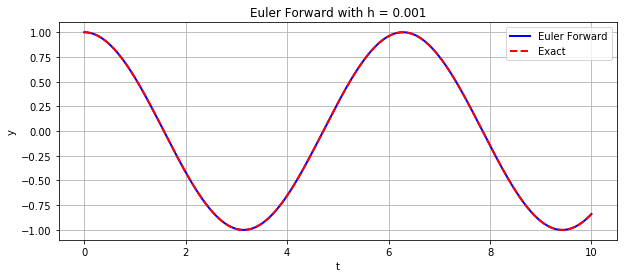

Maximum value reached: 1.00e+00

Trying with h = 0.001...


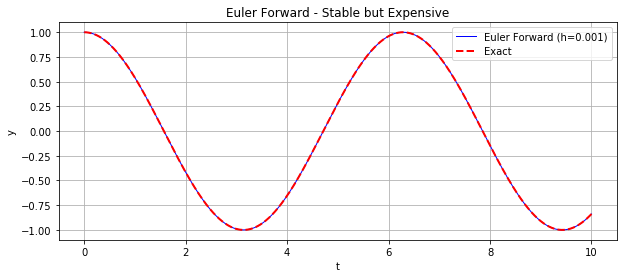

Number of steps needed: 10001
Maximum error: 5.00e-07


In [3]:
def euler_forward(f, y0, t0, t_final, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)

    t[0] = t0
    y[0] = y0

    # Time stepping
    for n in range(num_steps):
        y[n+1] = y[n] + h * f(t[n], y[n])
        t[n+1] = t[n] + h

    return t, y
# Initial condition
y0 = 1.0
t0 = 0.0
t_final = 10.0

# Try Euler's Forward with h = 0.01
h_forward = 0.001
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, y_forward = euler_forward(f, y0, t0, t_final, h_forward)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(t_forward, y_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('y')
    plt.title(f'Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Maximum value reached: {np.max(np.abs(y_forward)):.2e}")
except:
    print("Solution blew up!")
# Try with MUCH smaller step size
h_forward_stable = 0.001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, y_forward = euler_forward(f, y0, t0, t_final, h_forward_stable)

plt.figure(figsize=(10, 4))
plt.plot(t_forward, y_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, y_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('y')
plt.title('Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(y_forward - y_exact(t_forward))):.2e}")

## Part 2: Building the Newton-Raphson Solver



### Step 2.1: Define the Residual Function


```python
def residual(y_next, y_n, t_next, h):
    """
    Residual function for implicit Euler.
    
    We want to solve: y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})
    
    Rearrange: g(y_{n+1}) = y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1}) = 0
    
    Parameters:
    - y_next: the unknown y_{n+1} we're solving for
    - y_n: the known value at previous time step
    - t_next: time t_{n+1}
    - h: step size
    
    Returns: residual g(y_{n+1})
    """
    return y_next - y_n - h * f(t_next, y_next)
```


```python
# Test the residual
t_test = 1.0
h_test = 0.1
y_n_test = np.cos(t_test)
y_next_test = np.cos(t_test + h_test)

g_test = residual(y_next_test, y_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")
```

In [4]:
def residual(y_next, y_n, t_next, h):
    """
    Residual function for implicit Euler.

    We want to solve: y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})

    Rearrange: g(y_{n+1}) = y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1}) = 0

    Parameters:
    - y_next: the unknown y_{n+1} we're solving for
    - y_n: the known value at previous time step
    - t_next: time t_{n+1}
    - h: step size

    Returns: residual g(y_{n+1})
    """
    return y_next - y_n - h * f(t_next, y_next)
# Test the residual
t_test = 1.0
h_test = 0.1
y_n_test = np.cos(t_test)
y_next_test = np.cos(t_test + h_test)

g_test = residual(y_next_test, y_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")

Residual when using exact solution: 2.41e-03
(Should be very close to zero)


### Step 2.2: Compute the Derivative of the Residual

```
g(y_{n+1}) = y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1})

Taking derivative with respect to y_{n+1}:

g'(y_{n+1}) = d/d(y_{n+1}) [y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1})]

            = 1 - 0 - h * (df/dy)|_{t_{n+1}, y_{n+1}}
            
            = 1 - h * (df/dy)

For our specific problem: f(t,y) = -1000(y - cos(t)) - sin(t)
                                  = -1000*y + 1000*cos(t) - sin(t)

So: df/dy = -1000 = -lambda

Therefore: g'(y_{n+1}) = 1 - h*(-1000) = 1 + 1000*h
```


```python
def residual_derivative(h):
    """
    Derivative of residual with respect to y_{n+1}.
    
    For our problem: f(t,y) = -lambda*y + g(t)
    So: df/dy = -lambda
    
    Therefore: g'(y_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h
    
    This is CONSTANT for our linear problem!
    
    Parameters:
    - h: step size
    
    Returns: g'(y_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy
```

```python
# Verify with finite differences
def residual_derivative_numerical(y_next, y_n, t_next, h, eps=1e-8):
    """Numerical approximation of g' using finite differences"""
    return (residual(y_next + eps, y_n, t_next, h) - 
            residual(y_next - eps, y_n, t_next, h)) / (2 * eps)

# Test at a random point
y_test = 0.5
g_prime_analytical = residual_derivative(h_test)
g_prime_numerical = residual_derivative_numerical(y_test, y_n_test, t_test, h_test)

print(f"Analytical g': {g_prime_analytical:.6f}")
print(f"Numerical g':  {g_prime_numerical:.6f}")
print(f"Difference:    {abs(g_prime_analytical - g_prime_numerical):.2e}")
```

In [5]:
def residual_derivative(h):
    """
    Derivative of residual with respect to y_{n+1}.

    For our problem: f(t,y) = -lambda*y + g(t)
    So: df/dy = -lambda

    Therefore: g'(y_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h

    This is CONSTANT for our linear problem!

    Parameters:
    - h: step size

    Returns: g'(y_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy
# Verify with finite differences
def residual_derivative_numerical(y_next, y_n, t_next, h, eps=1e-8):
    """Numerical approximation of g' using finite differences"""
    return (residual(y_next + eps, y_n, t_next, h) - 
            residual(y_next - eps, y_n, t_next, h)) / (2 * eps)

# Test at a random point
y_test = 0.5
g_prime_analytical = residual_derivative(h_test)
g_prime_numerical = residual_derivative_numerical(y_test, y_n_test, t_test, h_test)

print(f"Analytical g': {g_prime_analytical:.6f}")
print(f"Numerical g':  {g_prime_numerical:.6f}")
print(f"Difference:    {abs(g_prime_analytical - g_prime_numerical):.2e}")

Analytical g': 101.000000
Numerical g':  101.000000
Difference:    2.08e-07


### Step 2.3: Implement Newton-Raphson

```python
def newton_raphson_step(y_n, t_next, h, tol=1e-8, max_iter=20, verbose=False):
    """
    Solve for y_{n+1} using Newton-Raphson iteration.
    
    We want to find y_{n+1} such that g(y_{n+1}) = 0
    
    Newton-Raphson: y^(k+1) = y^(k) - g(y^(k)) / g'(y^(k))
    
    Parameters:
    - y_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details
    
    Returns: (y_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    y_guess = y_n + h * f(t_next - h, y_n)  # or just y_n works too
    
    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)
    
    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: y = {y_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")
    
    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(y_guess, y_n, t_next, h)
        
        if verbose:
            print(f"  Iteration {k}: y = {y_guess:.6f}, g = {g:.2e}")
        
        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return y_guess, k
        
        # Newton-Raphson update
        delta = -g / g_prime
        y_guess = y_guess + delta
    
    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter
```

```python
# Test Newton-Raphson on one step
y_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

y_next, iters = newton_raphson_step(y_n, t_n + h, h, verbose=True)

print(f"Result: y({t_n + h}) = {y_next:.6f}")
print(f"Exact:  y({t_n + h}) = {y_exact(t_n + h):.6f}")
print(f"Error:  {abs(y_next - y_exact(t_n + h)):.2e}")
```


In [6]:
def newton_raphson_step(y_n, t_next, h, tol=1e-8, max_iter=20, verbose=False):
    """
    Solve for y_{n+1} using Newton-Raphson iteration.

    We want to find y_{n+1} such that g(y_{n+1}) = 0

    Newton-Raphson: y^(k+1) = y^(k) - g(y^(k)) / g'(y^(k))

    Parameters:
    - y_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details

    Returns: (y_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    y_guess = y_n + h * f(t_next - h, y_n)  # or just y_n works too

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: y = {y_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(y_guess, y_n, t_next, h)

        if verbose:
            print(f"  Iteration {k}: y = {y_guess:.6f}, g = {g:.2e}")

        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return y_guess, k

        # Newton-Raphson update
        delta = -g / g_prime
        y_guess = y_guess + delta

    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter
# Test Newton-Raphson on one step
y_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

y_next, iters = newton_raphson_step(y_n, t_n + h, h, verbose=True)

print(f"Result: y({t_n + h}) = {y_next:.6f}")
print(f"Exact:  y({t_n + h}) = {y_exact(t_n + h):.6f}")
print(f"Error:  {abs(y_next - y_exact(t_n + h)):.2e}")


  Starting Newton-Raphson at t = 0.1000
  Initial guess: y = 1.000000
  g'(constant) = 101.000000

  Iteration 0: y = 1.000000, g = 5.10e-01
  Iteration 1: y = 0.994955, g = 7.49e-16
  ✓ Converged in 1 iterations!

Result: y(0.1) = 0.994955
Exact:  y(0.1) = 0.995004
Error:  4.94e-05


## Part 3: Complete Euler's Backward Implementation


### Step 3.1: The Full Solver

```python
def euler_backward(f, y0, t0, t_final, h, tol=1e-8, verbose_freq=0):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.
    
    For each time step:
    1. Solve y_{n+1} = y_n + h*f(t_{n+1}, y_{n+1}) using Newton-Raphson
    2. Move to next time step
    
    Parameters:
    - f: ODE function dy/dt = f(t, y)
    - y0: initial condition
    - t0, t_final: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)
    
    Returns:
    - t: array of time points
    - y: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)
    
    # Initial condition
    t[0] = t0
    y[0] = y0
    
    print(f"Starting Euler's Backward method:")
    print(f"  Time span: [{t0}, {t_final}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")
    
    # Time stepping loop
    for n in range(num_steps):
        # Solve for y_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))
        
        y[n+1], iterations[n] = newton_raphson_step(
            y[n], t[n] + h, h, tol=tol, verbose=verbose
        )
        
        t[n+1] = t[n] + h
    
    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}\n")
    
    return t, y, iterations
```


In [7]:
def euler_backward(f, y0, t0, t_final, h, tol=1e-8, verbose_freq=0):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.

    For each time step:
    1. Solve y_{n+1} = y_n + h*f(t_{n+1}, y_{n+1}) using Newton-Raphson
    2. Move to next time step

    Parameters:
    - f: ODE function dy/dt = f(t, y)
    - y0: initial condition
    - t0, t_final: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)

    Returns:
    - t: array of time points
    - y: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    y[0] = y0

    print(f"Starting Euler's Backward method:")
    print(f"  Time span: [{t0}, {t_final}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")

    # Time stepping loop
    for n in range(num_steps):
        # Solve for y_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))

        y[n+1], iterations[n] = newton_raphson_step(
            y[n], t[n] + h, h, tol=tol, verbose=verbose
        )

        t[n+1] = t[n] + h

    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}\n")

    return t, y, iterations

### Step 3.2: Test with Different Step Sizes

```python
# Test with h = 0.1 (100x larger than stable Euler Forward!)
print("=" * 60)
print("TEST 1: h = 0.1 (very large for a stiff problem)")
print("=" * 60)

h_backward = 0.1
t_backward, y_backward, iters = euler_backward(
    f, y0, t0, t_final, h_backward, verbose_freq=20
)

# Plot results
plt.figure(figsize=(12, 8))

# Solution comparison
plt.subplot(2, 2, 1)
plt.plot(t_backward, y_backward, 'b-o', markersize=4, label='Implicit Euler')
plt.plot(t_backward, y_exact(t_backward), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('y')
plt.title(f'Solution (h = {h_backward})')
plt.legend()
plt.grid(True)

# Error
plt.subplot(2, 2, 2)
error = np.abs(y_backward - y_exact(t_backward))
plt.semilogy(t_backward, error, 'b-o', markersize=4)
plt.xlabel('t')
plt.ylabel('|Error|')
plt.title('Absolute Error (log scale)')
plt.grid(True)

# Newton-Raphson iterations
plt.subplot(2, 2, 3)
plt.plot(t_backward[:-1], iters, 'go-', markersize=4)
plt.xlabel('t')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Convergence')
plt.grid(True)

# Histogram of iterations
plt.subplot(2, 2, 4)
plt.hist(iters, bins=range(int(np.min(iters)), int(np.max(iters))+2), 
         edgecolor='black', alpha=0.7)
plt.xlabel('NR Iterations')
plt.ylabel('Frequency')
plt.title('Distribution of NR Iterations')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Maximum error: {np.max(error):.2e}")
print(f"Number of steps: {len(t_backward)}")
```


```python
# Test with h = 0.5 (even bigger!)
print("\n" + "=" * 60)
print("TEST 2: h = 0.5 (extremely large)")
print("=" * 60)

h_large = 0.5
t_large, y_large, iters_large = euler_backward(f, y0, t0, t_final, h_large)

plt.figure(figsize=(10, 4))
plt.plot(t_large, y_large, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_large, y_exact(t_large), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution with Very Large Step Size')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(y_large - y_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")
```


TEST 1: h = 0.1 (very large for a stiff problem)
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.1
  Number of steps: 100
  NR tolerance: 1e-08


  Starting Newton-Raphson at t = 0.1000
  Initial guess: y = 1.000000
  g'(constant) = 101.000000

  Iteration 0: y = 1.000000, g = 5.10e-01
  Iteration 1: y = 0.994955, g = 7.49e-16
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 2.1000
  Initial guess: y = -0.508980
  g'(constant) = 101.000000

  Iteration 0: y = -0.508980, g = -4.20e-01
  Iteration 1: y = -0.504822, g = 3.86e-15
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 4.1000
  Initial guess: y = -0.581324
  g'(constant) = 101.000000

  Iteration 0: y = -0.581324, g = -6.60e-01
  Iteration 1: y = -0.574794, g = -4.30e-16
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 6.1000
  Initial guess: y = 0.992813
  g'(constant) = 101.000000

  Iteration 0: y = 0.992813, g = 9.69e-01
  Iteration 1: y = 0.98322

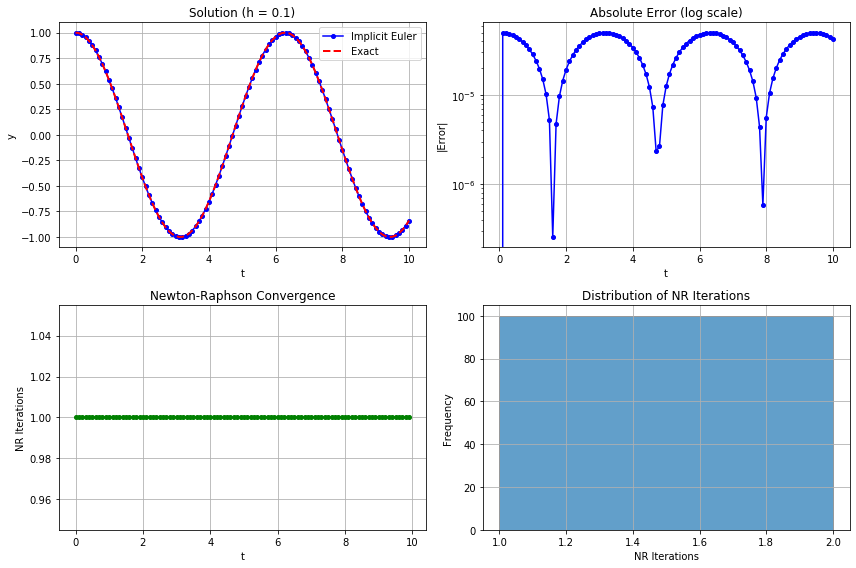

Maximum error: 5.00e-05
Number of steps: 101

TEST 2: h = 0.5 (extremely large)
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.5
  Number of steps: 20
  NR tolerance: 1e-08

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



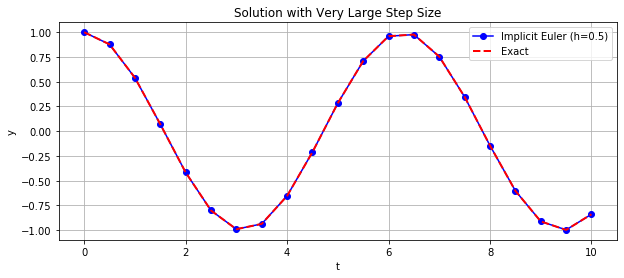

Maximum error: 2.48e-04
Number of steps: 21


In [8]:
# Test with h = 0.1 (100x larger than stable Euler Forward!)
print("=" * 60)
print("TEST 1: h = 0.1 (very large for a stiff problem)")
print("=" * 60)

h_backward = 0.1
t_backward, y_backward, iters = euler_backward(
    f, y0, t0, t_final, h_backward, verbose_freq=20
)

# Plot results
plt.figure(figsize=(12, 8))

# Solution comparison
plt.subplot(2, 2, 1)
plt.plot(t_backward, y_backward, 'b-o', markersize=4, label='Implicit Euler')
plt.plot(t_backward, y_exact(t_backward), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('y')
plt.title(f'Solution (h = {h_backward})')
plt.legend()
plt.grid(True)

# Error
plt.subplot(2, 2, 2)
error = np.abs(y_backward - y_exact(t_backward))
plt.semilogy(t_backward, error, 'b-o', markersize=4)
plt.xlabel('t')
plt.ylabel('|Error|')
plt.title('Absolute Error (log scale)')
plt.grid(True)

# Newton-Raphson iterations
plt.subplot(2, 2, 3)
plt.plot(t_backward[:-1], iters, 'go-', markersize=4)
plt.xlabel('t')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Convergence')
plt.grid(True)

# Histogram of iterations
plt.subplot(2, 2, 4)
plt.hist(iters, bins=range(int(np.min(iters)), int(np.max(iters))+2), 
         edgecolor='black', alpha=0.7)
plt.xlabel('NR Iterations')
plt.ylabel('Frequency')
plt.title('Distribution of NR Iterations')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Maximum error: {np.max(error):.2e}")
print(f"Number of steps: {len(t_backward)}")
# Test with h = 0.5 (even bigger!)
print("\n" + "=" * 60)
print("TEST 2: h = 0.5 (extremely large)")
print("=" * 60)

h_large = 0.5
t_large, y_large, iters_large = euler_backward(f, y0, t0, t_final, h_large)

plt.figure(figsize=(10, 4))
plt.plot(t_large, y_large, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_large, y_exact(t_large), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Solution with Very Large Step Size')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(y_large - y_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")

## Part 4: Analysis and Comparison


### Step 4.1: Step Size Study

```python
# Compare different step sizes
step_sizes = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
results = []

print("Running step size study...")
print(f"{'h':>8} | {'Method':^15} | {'Steps':>6} | {'Max Error':>12} | {'Avg NR Iter':>12}")
print("-" * 70)

for h in step_sizes:
    # Euler's Backward
    t_eb, y_eb, iters_eb = euler_backward(f, y0, t0, t_final, h, verbose_freq=0)
    error_eb = np.max(np.abs(y_eb - y_exact(t_eb)))
    avg_iters = np.mean(iters_eb)
    
    print(f"{h:8.3f} | {'Implicit':^15} | {len(t_eb):6d} | {error_eb:12.2e} | {avg_iters:12.2f}")
    
    results.append({
        'h': h,
        'method': 'Implicit',
        'steps': len(t_eb),
        'error': error_eb,
        'avg_iters': avg_iters
    })
    
    # Euler's Forward (only for small h where it's stable)
    if h <= 0.001:
        t_ef, y_ef = euler_forward(f, y0, t0, t_final, h)
        error_ef = np.max(np.abs(y_ef - y_exact(t_ef)))
        print(f"{h:8.3f} | {'Explicit':^15} | {len(t_ef):6d} | {error_ef:12.2e} | {'N/A':>12}")
```

In [9]:
# Compare different step sizes
step_sizes = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
results = []

print("Running step size study...")
print(f"{'h':>8} | {'Method':^15} | {'Steps':>6} | {'Max Error':>12} | {'Avg NR Iter':>12}")
print("-" * 70)

for h in step_sizes:
    # Euler's Backward
    t_eb, y_eb, iters_eb = euler_backward(f, y0, t0, t_final, h, verbose_freq=0)
    error_eb = np.max(np.abs(y_eb - y_exact(t_eb)))
    avg_iters = np.mean(iters_eb)

    print(f"{h:8.3f} | {'Implicit':^15} | {len(t_eb):6d} | {error_eb:12.2e} | {avg_iters:12.2f}")

    results.append({
        'h': h,
        'method': 'Implicit',
        'steps': len(t_eb),
        'error': error_eb,
        'avg_iters': avg_iters
    })

    # Euler's Forward (only for small h where it's stable)
    if h <= 0.001:
        t_ef, y_ef = euler_forward(f, y0, t0, t_final, h)
        error_ef = np.max(np.abs(y_ef - y_exact(t_ef)))
        print(f"{h:8.3f} | {'Explicit':^15} | {len(t_ef):6d} | {error_ef:12.2e} | {'N/A':>12}")

Running step size study...
       h |     Method      |  Steps |    Max Error |  Avg NR Iter
----------------------------------------------------------------------
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.001
  Number of steps: 10000
  NR tolerance: 1e-08

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 0

   0.001 |    Implicit     |  10001 |     5.00e-07 |         1.00
   0.001 |    Explicit     |  10001 |     5.00e-07 |          N/A
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.01
  Number of steps: 1000
  NR tolerance: 1e-08

✓ Completed!
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1

   0.010 |    Implicit     |   1001 |     5.00e-06 |         1.00
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.05
  Number of steps: 200
  NR tolerance: 1e-08

✓ Completed!
  Average NR iterations per step: 1.00
  M

### Step 4.2: Visualize the Comparison

```python
# Extract data for plotting
h_values = [r['h'] for r in results]
errors = [r['error'] for r in results]
steps = [r['steps'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Error vs step size
ax1.loglog(h_values, errors, 'bo-', linewidth=2, markersize=8, label='Implicit Euler')
ax1.loglog(h_values, h_values, 'k--', label='O(h) reference', alpha=0.5)
ax1.set_xlabel('Step size h', fontsize=12)
ax1.set_ylabel('Maximum Error', fontsize=12)
ax1.set_title('Accuracy vs Step Size', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Number of steps vs step size
ax2.loglog(h_values, steps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Step size h', fontsize=12)
ax2.set_ylabel('Number of Steps', fontsize=12)
ax2.set_title('Computational Cost vs Step Size', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```


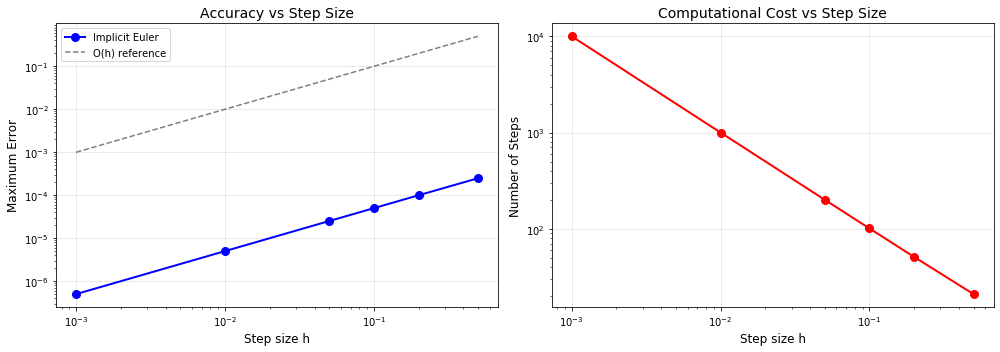

In [10]:
# Extract data for plotting
h_values = [r['h'] for r in results]
errors = [r['error'] for r in results]
steps = [r['steps'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Error vs step size
ax1.loglog(h_values, errors, 'bo-', linewidth=2, markersize=8, label='Implicit Euler')
ax1.loglog(h_values, h_values, 'k--', label='O(h) reference', alpha=0.5)
ax1.set_xlabel('Step size h', fontsize=12)
ax1.set_ylabel('Maximum Error', fontsize=12)
ax1.set_title('Accuracy vs Step Size', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Number of steps vs step size
ax2.loglog(h_values, steps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Step size h', fontsize=12)
ax2.set_ylabel('Number of Steps', fontsize=12)
ax2.set_title('Computational Cost vs Step Size', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 4.3: The Bottom Line

```python
print("\n" + "=" * 70)
print("SUMMARY: Why Implicit Methods Matter for Stiff Problems")
print("=" * 70)

print(f"\nProblem stiffness parameter: λ = {lam}")
print(f"Time scale ratio: ~{lam}")

print("\n1. EULER'S FORWARD (Explicit):")
print(f"   - Maximum stable step size: h ≈ {2/lam:.6f}")
print(f"   - Steps needed for t=[0,10]: ~{int(10/(2/lam))}")
print(f"   - Stability dictates step size (not accuracy!)")

print("\n2. EULER'S BACKWARD (Implicit):")
print(f"   - Stable for any h > 0")
print(f"   - With h = 0.1: only {int(10/0.1)} steps")
print(f"   - With h = 0.5: only {int(10/0.5)} steps")
print(f"   - Accuracy dictates step size")

print("\n3. COMPUTATIONAL TRADE-OFF:")
print(f"   - Explicit: Cheap per step, but many steps needed")
print(f"   - Implicit: Expensive per step (NR iteration), but fewer steps")
print(f"   - For stiff problems: Implicit wins by orders of magnitude!")

print("\n4. KEY INSIGHT:")
print("   Stiffness = when stability requirement >> accuracy requirement")
print("   Implicit methods decouple these requirements")
print("=" * 70)
```


## Part 5: Extending to Your Project


### Example: RC Circuit Problem

```python
# RC Circuit: dV/dt = -V/RC + V_source/RC
# With RC = 1e-7, V_source(t) = 5*sin(t)

RC = 1e-7
lam_RC = 1/RC  # = 1e7

def f_RC(t, V):
    """RC circuit ODE"""
    V_source = 5 * np.sin(t)
    return -V / RC + V_source / RC

def residual_derivative_RC(h):
    """g' for RC circuit"""
    df_dV = -1/RC
    return 1 - h * df_dV

print(f"RC Circuit stiffness parameter: λ = {lam_RC:.2e}")
print(f"This is {lam_RC/lam:.0f}x stiffer than our example!")
print(f"\nYou would use the SAME Newton-Raphson structure,")
print(f"just with f_RC and residual_derivative_RC.")
```

## Part 6: Q&A and Tips


### Common Issues and Solutions

```python
print("DEBUGGING CHECKLIST:")
print("=" * 70)
print("\n1. Newton-Raphson not converging?")
print("   → Check that g' is correct (compare to finite differences)")
print("   → Try smaller h")
print("   → Check your initial guess")

print("\n2. Solution looks wrong?")
print("   → Verify f(t,y) is correct (plug in analytical solution)")
print("   → Check signs in residual function")
print("   → Plot at each step to see where it goes wrong")

print("\n3. Slow convergence?")
print("   → For linear problems, should converge in 1-3 iterations")
print("   → If taking 10+ iterations, something is wrong")

print("\n4. How to verify your solution?")
print("   → Compare to analytical solution (if available)")
print("   → Compare to SciPy's solve_ivp with 'Radau' method")
print("   → Check that physical constraints are satisfied")

print("\n5. How to choose step size?")
print("   → Start large (h = 0.5), see if stable")
print("   → Reduce h until error is acceptable")
print("   → Make a convergence plot (error vs h)")
print("=" * 70)
```

### Verification Template

```python
def verify_solution(t, y_numerical, y_analytical_func, method_name=""):
    """
    Template for verifying your solution
    """
    y_exact = y_analytical_func(t)
    error = np.abs(y_numerical - y_exact)
    
    print(f"\nVERIFICATION REPORT: {method_name}")
    print("=" * 50)
    print(f"Maximum absolute error: {np.max(error):.2e}")
    print(f"Mean absolute error:    {np.mean(error):.2e}")
    print(f"RMS error:              {np.sqrt(np.mean(error**2)):.2e}")
    
    # Relative error
    rel_error = error / (np.abs(y_exact) + 1e-10)
    print(f"Maximum relative error: {np.max(rel_error):.2e}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    
    ax1.plot(t, y_numerical, 'b-', label='Numerical', linewidth=2)
    ax1.plot(t, y_exact, 'r--', label='Exact', linewidth=2)
    ax1.set_xlabel('t')
    ax1.set_ylabel('y')
    ax1.set_title(f'{method_name}: Solution Comparison')
    ax1.legend()
    ax1.grid(True)
    
    ax2.semilogy(t, error, 'g-', linewidth=2)
    ax2.set_xlabel('t')
    ax2.set_ylabel('|Error|')
    ax2.set_title('Absolute Error (log scale)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Test it
verify_solution(t_backward, y_backward, y_exact, "Euler's Backward (h=0.1)")
```

## Wrap-Up


```python
print("\n" + "=" * 70)
print("WHAT WE BUILT TODAY:")
print("=" * 70)
print("""
1. ✓ Defined a stiff ODE problem
2. ✓ Showed why Euler's Forward fails (blows up with h=0.01)
3. ✓ Built residual function g(y_{n+1})
4. ✓ Computed derivative g'(y_{n+1})
5. ✓ Implemented Newton-Raphson iteration
6. ✓ Wrapped it in Euler's Backward time stepping
7. ✓ Tested with large step sizes (h=0.1, h=0.5)
8. ✓ Analyzed convergence, error, and computational cost
9. ✓ Created verification and visualization tools

KEY TAKEAWAYS:
- Implicit methods can handle much larger step sizes for stiff problems
- Newton-Raphson typically converges in just a few iterations
- The derivative g' is constant for linear problems (extra simple!)
- Always verify your solution against analytical or reference solutions
- Plot everything: solution, error, NR iterations

FOR YOUR PROJECT:
- Pick one of the 5 stiff scalar ODEs
- Follow this same structure
- Demonstrate stiffness (show Euler Forward fails)
- Implement Implicit Euler with Newton-Raphson
- Analyze performance vs explicit methods
""")
print("=" * 70)

```

## Practice


```python
print("\nPRACTICE EXERCISES:")
print("=" * 70)
print("""
1. MODIFY THE STIFFNESS:
   Change lam = 1000 to lam = 100, then lam = 10000
   - How does max stable h for Euler Forward change?
   - Does Implicit Euler still work?

2. TRY A DIFFERENT FORCING:
   Change g(t) from cos(t) to:
   - g(t) = exp(-t/10) (decaying)
   - g(t) = t (ramp)
   How does this affect convergence?

3. IMPLEMENT EXPLICIT EULER YOURSELF:
   Make sure you understand both methods by coding both from scratch

4. START YOUR PROJECT:
   Pick one of the 5 options and set up the f(t,y) function
   Find the analytical solution (or verify with SciPy)

5. CHALLENGE: 
   What happens if you use Euler Forward prediction as initial guess
   instead of just y_n? Does NR converge faster?
""")
print("=" * 70)
```

## Complete Code Summary


```python
"""
COMPLETE WORKING CODE FOR EULER'S BACKWARD WITH NEWTON-RAPHSON
================================================================

Copy this into your Jupyter notebook and run cell by cell!
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# PROBLEM DEFINITION
# ============================================================================

lam = 1000.0  # Stiffness parameter

def f(t, y):
    """ODE: dy/dt = -lam*(y - cos(t)) - sin(t)"""
    return -lam * (y - np.cos(t)) - np.sin(t)

def y_exact(t):
    """Analytical solution: y(t) = cos(t)"""
    return np.cos(t)

# ============================================================================
# NEWTON-RAPHSON COMPONENTS
# ============================================================================

def residual(y_next, y_n, t_next, h):
    """g(y_{n+1}) = y_{n+1} - y_n - h*f(t_{n+1}, y_{n+1})"""
    return y_next - y_n - h * f(t_next, y_next)

def residual_derivative(h):
    """g'(y_{n+1}) = 1 - h*(df/dy) = 1 + lam*h"""
    return 1 + lam * h

def newton_raphson_step(y_n, t_next, h, tol=1e-8, max_iter=20):
    """Solve for y_{n+1} using Newton-Raphson"""
    y_guess = y_n
    g_prime = residual_derivative(h)
    
    for k in range(max_iter):
        g = residual(y_guess, y_n, t_next, h)
        if abs(g) < tol:
            return y_guess, k
        delta = -g / g_prime
        y_guess = y_guess + delta
    
    return y_guess, max_iter

# ============================================================================
# EULER'S BACKWARD SOLVER
# ============================================================================

def euler_backward(f, y0, t0, t_final, h, tol=1e-8):
    """Complete Euler's Backward solver"""
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    y = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)
    
    t[0] = t0
    y[0] = y0
    
    for n in range(num_steps):
        y[n+1], iterations[n] = newton_raphson_step(y[n], t[n] + h, h, tol)
        t[n+1] = t[n] + h
    
    return t, y, iterations

# ============================================================================
# RUN IT!
# ============================================================================

if __name__ == "__main__":
    # Solve the problem
    y0 = 1.0
    t0 = 0.0
    t_final = 10.0
    h = 0.1
    
    t, y, iters = euler_backward(f, y0, t0, t_final, h)
    
    # Plot
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, y, 'b-o', label='Numerical', markersize=4)
    plt.plot(t, y_exact(t), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('y')
    plt.title(f'Solution (h={h})')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.semilogy(t, np.abs(y - y_exact(t)), 'g-o', markersize=4)
    plt.xlabel('t')
    plt.ylabel('|Error|')
    plt.title('Absolute Error')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Max error: {np.max(np.abs(y - y_exact(t))):.2e}")
    print(f"Avg NR iterations: {np.mean(iters):.2f}")
```